## Calculate Pi using Python

#### Method 1: Circle and Square
Pick random locations (x,y) inside a square with corners at +/-1. Approximate pi based on how many of the locations are inside the center circle. The python code below shows that this approach works, but it is quite inefficient at approximating pi.

N=2000 => approximate pi=3.108
Real pi=3.141592653589793


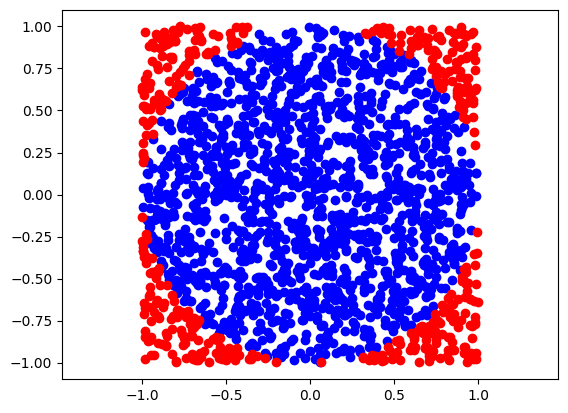

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

N = 2000
inside_circle = 0
xvec = np.zeros(N)
yvec = np.zeros(N)
for i in range(N):
    xvec[i] = random.uniform(-1, 1)
    yvec[i] = random.uniform(-1, 1)
    radius = math.sqrt(xvec[i]**2 + yvec[i]**2)
    if radius < 1:
        inside_circle += 1

rr = np.sqrt(xvec**2 + yvec**2)

plt.scatter(xvec[rr<1], yvec[rr<1], c='b')
plt.scatter(xvec[rr>1], yvec[rr>1], c='r')
plt.axis('equal')

approximate_pi = 4 * inside_circle / N
print(f"N={N} => approximate pi={approximate_pi}")
print(f"Real pi={math.pi}")

#### Method 2: Square - Circle - Square

N=2000 => approximate pi=3.1290000000000004
Real pi=3.141592653589793


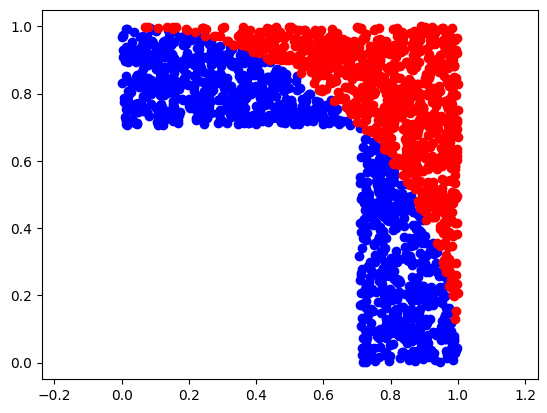

In [2]:
N = 2000
inside_circle = 0
xvec = np.array([])
yvec = np.array([])
while len(xvec) < N:
    x = random.uniform(0, 1)
    y = random.uniform(0, 1)
    if x < 1/math.sqrt(2) and y < 1/math.sqrt(2):
        continue
    xvec = np.append(xvec, x)
    yvec = np.append(yvec, y)
    radius = math.sqrt(x**2 + y**2)
    if radius < 1:
        inside_circle += 1

rr = np.sqrt(xvec**2 + yvec**2)

plt.scatter(xvec[rr<1], yvec[rr<1], c='b')
plt.scatter(xvec[rr>1], yvec[rr>1], c='r')
plt.axis('equal')

R = inside_circle / (N - inside_circle)
approximate_pi = 2 * (2*R+1) / (R+1)
print(f"N={N} => approximate pi={approximate_pi}")
print(f"Real pi={math.pi}")

#### Method 3

MacLaurin series based on: $$\pi = 4 \text{ arctan(1)}$$ which can be written $$\pi = 4 \left( 1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + ... \right)$$ This method also works but is inefficient.

In [3]:
N = 1000
sum = 0
sign = 1
for i in range(1, 2*N, 2):
    sum += sign/i
    sign *= -1

approx_pi = 4 * sum
print(f"N={N} => approximate pi={approx_pi}")
print(f"Real pi={math.pi}")

N=1000 => approximate pi=3.140592653839794
Real pi=3.141592653589793


#### Method 4
A much faster converging approximation of pi was proposed by Srinivasa Ramanujan in 1910. Here is one implementation:

In [4]:
N = 3
sum = 0
for k in range(N):
    sum += math.factorial(4*k) * (1103 + 26390*k) / (math.factorial(k)**4 * 396**(4*k))

approx_pi = 9801 / sum / (math.sqrt(2) * 2)
print(f"N={N} => approximate pi={approx_pi}")
print(f"Real pi={math.pi}")

N=3 => approximate pi=3.141592653589793
Real pi=3.141592653589793


#### Python Arbitrary Precision Math
If you just want to know pi to some given precision, then you can also use the mpmath library. Here's one example:

In [5]:
from mpmath import *
mp.dps = 80
mp.pretty = True
print(+pi)
print(4 * atan(1))

3.141592653589793238462643383279502884197169399375105820974944592307816406286209
3.141592653589793238462643383279502884197169399375105820974944592307816406286209


In [13]:
import math
math.pi

3.141592653589793

In [15]:
format(math.pi, '.50g')

'3.141592653589793115997963468544185161590576171875'

In [16]:
math.pi.as_integer_ratio()

(884279719003555, 281474976710656)

In [19]:
884279719003555 / 281474976710656 == math.pi

True